# Vehicle Price Model KPI Report

## Executive Summary

This notebook rebuilds the model-output readout from the saved artifacts produced by `ML/Price_ML_Models.py` and `ML/Time_Series_Price.py`. It is intended to be rerun after model training so the KPI tables, segment checks, and forecast coverage update from the latest JSON/CSV outputs.


In [41]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib

try:
    ipython_shell = get_ipython()
except NameError:
    ipython_shell = None

if ipython_shell is not None and ipython_shell.__class__.__name__ == "ZMQInteractiveShell":
    ipython_shell.run_line_magic("matplotlib", "inline")
else:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

matplotlib.rcParams["figure.dpi"] = 120

def show_matplotlib(fig):
    """Render a Matplotlib figure reliably in notebooks and close it after display."""
    display(fig)
    plt.close(fig)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "ML":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "MODELS_OUTPUT"
CURRENT_REPORT_PATH = OUTPUT_DIR / "model_report.json"
COHORT_REPORT_PATH = OUTPUT_DIR / "cohort_depreciation_model_report.json"
FORECAST_PATH = OUTPUT_DIR / "cohort_future_forecasts.csv"
BACKTEST_RESULTS_PATH = OUTPUT_DIR / "cohort_backtesting_results.csv"
BACKTEST_KPI_PATH = OUTPUT_DIR / "cohort_backtesting_kpis.csv"
TOP_MODEL_WEIGHT_ROWS = 30

def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing required report: {path}")
    return json.loads(path.read_text(encoding="utf-8"))

def load_forecast_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    for column in ["observed_month_start", "observed_week_start", "forecast_date"]:
        if column in df.columns:
            df[column] = pd.to_datetime(df[column], errors="coerce")
    for column in [
        "forecast_month",
        "forecast_horizon_days",
        "predicted_depreciation_pct",
        "predicted_median_price",
        "observed_median_price",
        "unique_vins",
        "volume",
    ]:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")
    return df

def load_backtest_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    for column in ["origin_month_start", "forecast_date"]:
        if column in df.columns:
            df[column] = pd.to_datetime(df[column], errors="coerce")
    numeric_columns = [
        "forecast_month",
        "observed_median_price",
        "actual_median_price",
        "predicted_median_price",
        "actual_depreciation_pct",
        "predicted_depreciation_pct",
        "absolute_error",
        "naive_absolute_error",
        "future_price_mae",
        "future_price_wape",
        "future_price_mae_skill_vs_naive",
        "depreciation_mae_pct_points",
        "backtest_rows",
        "backtest_cohorts",
    ]
    for column in numeric_columns:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")
    return df

current_report = load_json(CURRENT_REPORT_PATH)
cohort_report = load_json(COHORT_REPORT_PATH)
forecast_df = load_forecast_csv(FORECAST_PATH)
backtest_results_df = load_backtest_csv(BACKTEST_RESULTS_PATH)
backtest_kpis_df = load_backtest_csv(BACKTEST_KPI_PATH)

In [42]:
def money(value):
    if pd.isna(value):
        return "n/a"
    return f"${value:,.0f}"

def pct(value, digits=1):
    if pd.isna(value):
        return "n/a"
    return f"{value:.{digits}%}"

def decimal(value, digits=3):
    if pd.isna(value):
        return "n/a"
    return f"{value:.{digits}f}"

def horizon_months_from_target(target: str) -> int:
    try:
        token = str(target).split("_")[-1]
        if token.endswith("m"):
            return int(token.removesuffix("m"))
        if token.endswith("d"):
            return max(1, round(int(token.removesuffix("d")) / 30))
        return int(token)
    except Exception:
        return -1

def segment_metric(model_metrics: dict, segment_name: str, segment_value: str, metric: str = "mae"):
    return (
        model_metrics
        .get("segment_metrics", {})
        .get(segment_name, {})
        .get(segment_value, {})
        .get(metric, np.nan)
    )

def value_segment_rows(report: dict) -> list[dict]:
    rows = []
    for model_name, metrics in report.get("models", {}).items():
        for segment_value, stats in metrics.get("segment_metrics", {}).get("is_high_value", {}).items():
            rows.append(
                {
                    "model": model_name,
                    "vehicle_value_segment": segment_value,
                    "rows": stats.get("rows", 0),
                    "mae": stats.get("mae", np.nan),
                    "global_mae": metrics.get("mae", np.nan),
                }
            )
    return rows

def current_value_segment_table(report: dict) -> pd.DataFrame:
    rows = value_segment_rows(report)
    if not rows:
        return pd.DataFrame(
            columns=[
                "model",
                "everyday_rows",
                "everyday_mae",
                "high_value_rows",
                "high_value_mae",
                "high_value_mae_lift",
            ]
        )
    raw = pd.DataFrame(rows)
    metrics = raw.pivot(index="model", columns="vehicle_value_segment", values="mae")
    counts = raw.pivot(index="model", columns="vehicle_value_segment", values="rows")
    out = pd.DataFrame(index=metrics.index)
    out["everyday_rows"] = counts.get("everyday")
    out["everyday_mae"] = metrics.get("everyday")
    out["high_value_rows"] = counts.get("high_value")
    out["high_value_mae"] = metrics.get("high_value")
    out["high_value_mae_lift"] = out["high_value_mae"] / out["everyday_mae"]
    return out.reset_index()

best_model = current_report["recommended_model"]
best_metrics = current_report["models"][best_model]
value_segment_kpis = current_value_segment_table(current_report)
best_value_segments = (
    value_segment_kpis[value_segment_kpis["model"].eq(best_model)].iloc[0]
    if not value_segment_kpis.empty and best_model in set(value_segment_kpis["model"])
    else None
)
cohort_models = cohort_report.get("models", {})
trained_cohort_models = {
    name: model for name, model in cohort_models.items()
    if not model.get("skipped") and model.get("metrics")
}
skipped_cohort_models = {
    name: model for name, model in cohort_models.items()
    if model.get("skipped")
}
cohort_summary_rows = []
for model_key, model in trained_cohort_models.items():
    metrics = model.get("metrics", {})
    target_name = model.get("target") or model_key
    cohort_summary_rows.append(
        {
            "model_key": model_key,
            "target": target_name,
            "model_family": model.get("model_family", "global_ml"),
            "forecast_method": model.get("forecast_method"),
            "horizon_months": horizon_months_from_target(target_name),
            "future_price_mae": metrics.get("future_price_mae"),
            "future_price_wape": metrics.get("future_price_wape"),
            "skill_vs_naive": metrics.get("future_price_mae_skill_vs_naive"),
            "depreciation_mae_pct_points": metrics.get("depreciation_mae_pct_points"),
            "bias_dollars": metrics.get("future_price_bias"),
            "depreciation_r2": metrics.get("depreciation_r2"),
            "backtest_rows": metrics.get("backtest_rows", model.get("test_rows")),
            "backtest_cohorts": metrics.get("backtest_cohorts", model.get("test_cohorts")),
        }
    )
cohort_summary = pd.DataFrame(cohort_summary_rows)
valid_cohort_summary = cohort_summary.dropna(subset=["skill_vs_naive"]) if not cohort_summary.empty else pd.DataFrame()
best_cohort = (
    valid_cohort_summary.sort_values(["skill_vs_naive", "future_price_wape"], ascending=[False, True]).iloc[0]
    if not valid_cohort_summary.empty
    else None
)
max_forecast_date = cohort_report.get("max_forecast_date")
last_observed_month = cohort_report.get("last_observed_month") or cohort_report.get("last_observed_week")

summary_lines = [
    f"- **Current-price winner:** `{best_model}` with MAE {money(best_metrics.get('mae'))}, RMSE {money(best_metrics.get('rmse'))}, MAPE {pct(best_metrics.get('mape'))}, and R2 {decimal(best_metrics.get('r2'))}.",
    f"- **Validation design:** {current_report['row_counts']['train_rows']:,} train rows and {current_report['row_counts']['test_rows']:,} test rows with VIN overlap of {current_report['split']['vin_overlap']}.",
]
if best_value_segments is not None and pd.notna(best_value_segments.get("high_value_mae")):
    summary_lines.append(
        "- **Value-segment check:** "
        f"`{best_model}` has everyday MAE {money(best_value_segments.get('everyday_mae'))} "
        f"across {best_value_segments.get('everyday_rows', 0):,.0f} test rows, versus high-value MAE "
        f"{money(best_value_segments.get('high_value_mae'))} across {best_value_segments.get('high_value_rows', 0):,.0f} rows. "
        "Use the split table below when readable-model RMSE/R2 is distorted by the high-value tail."
    )
summary_lines.append(
    f"- **Cohort forecast coverage:** latest observed cohort month is {last_observed_month}; saved forecasts extend to {max_forecast_date}."
)
if best_cohort is not None:
    summary_lines.append(
        "- **Best time-series KPI:** "
        f"`{best_cohort['model_family']}` / `{best_cohort['target']}` has the strongest skill vs no-change at {pct(best_cohort['skill_vs_naive'])}, "
        f"with future-price MAE {money(best_cohort['future_price_mae'])} and WAPE {pct(best_cohort['future_price_wape'])}."
    )
    if best_cohort["skill_vs_naive"] <= 0:
        summary_lines.append(
            "- **Forecast guardrail:** the best validated cohort model does not beat the no-change baseline on MAE, so treat the recursive forecasts as directional scenarios until more history improves baseline skill."
        )
if skipped_cohort_models:
    skipped = ", ".join(f"`{target}` ({model.get('skipped') or model.get('validation_warning')})" for target, model in skipped_cohort_models.items())
    summary_lines.append(f"- **Time-series caveat:** some model-family/horizon runs were skipped or lacked validation rows: {skipped}. Forecast and backtest CSVs identify model family and method explicitly.")

display(Markdown("\n".join(summary_lines)))

- **Current-price winner:** `LightGBM` with MAE $1,974, RMSE $6,265, MAPE 7.6%, and R2 0.938.
- **Validation design:** 2,678,670 train rows and 669,668 test rows with VIN overlap of 0.
- **Value-segment check:** `LightGBM` has everyday MAE $1,842 across 666,748 test rows, versus high-value MAE $32,273 across 2,920 rows. Use the split table below when readable-model RMSE/R2 is distorted by the high-value tail.
- **Cohort forecast coverage:** latest observed cohort month is 2026-07-01; saved forecasts extend to 2031-07-01.
- **Best time-series KPI:** `target_depreciation_pct_1m` has the strongest skill vs no-change at -14.0%, with future-price MAE $2,290 and WAPE 5.4%.
- **Forecast guardrail:** the best validated cohort model does not beat the no-change baseline on MAE, so treat the recursive forecasts as directional scenarios until more history improves baseline skill.

## Context & Methods

The KPI set follows common regression and forecast-evaluation practice:

- **MAE** is the primary business KPI because it is measured in dollars and is easy to interpret for vehicle pricing decisions.
- **RMSE** is retained because it penalizes large misses more heavily than MAE.
- **MAPE/WAPE/RMSLE** provide relative-error views for mixed price bands; MAPE is useful here because prices are positive, but it should not be the only KPI.
- **R2** is a model-fit signal, not a business KPI by itself.
- **Bias and naive-baseline skill** matter for time-series forecasts because a forecast can be low-error on average while still consistently overpricing or underpricing.
- **Segment MAE** by price band, high-value status, make, and model year checks whether the headline model hides weak slices.
- **Feature weights/importance** are reported for interpretability. Linear readable models expose signed coefficients; tree and LightGBM-style models expose model-native importance rankings, which are directional diagnostics rather than causal claims.

Research scan:

- Used-car pricing papers support supervised tabular models with vehicle attributes, mileage, market context, and careful feature selection.
- Recent used-car pricing research also emphasizes uncertainty and trustworthiness, which makes segment checks, bias, and baseline comparisons important model-output KPIs.
- Global time-series forecasting papers support training one model across many related cohort series, especially when individual series are short or sparse.
- Forecast-accuracy references recommend testing against simple baselines and using scale-aware error measures; this is why the depreciation model reports no-change baseline skill and WAPE in addition to raw dollar error.


In [43]:
metric_contract = pd.DataFrame(
    [
        {"KPI": "MAE", "Where used": "Current price and forecast future price", "Why it matters": "Average dollar miss; easiest business interpretation", "Direction": "Lower is better", "Notebook output": "current_model_kpis, cohort_kpis"},
        {"KPI": "RMSE", "Where used": "Current price and forecast future price", "Why it matters": "Penalizes large misses and outlier errors", "Direction": "Lower is better", "Notebook output": "current_model_kpis, cohort_kpis"},
        {"KPI": "MAPE / WAPE", "Where used": "Relative price error", "Why it matters": "Compares misses across different price levels", "Direction": "Lower is better", "Notebook output": "current_model_kpis, cohort_kpis"},
        {"KPI": "RMSLE", "Where used": "Current price", "Why it matters": "Tracks multiplicative error on skewed positive prices", "Direction": "Lower is better", "Notebook output": "current_model_kpis"},
        {"KPI": "R2", "Where used": "Model comparison", "Why it matters": "Explained variance; useful but not sufficient alone", "Direction": "Higher is better", "Notebook output": "current_model_kpis, cohort_kpis"},
        {"KPI": "Skill vs naive", "Where used": "Cohort forecasts", "Why it matters": "Shows whether the model beats a no-change price forecast", "Direction": "Higher is better; must be above 0", "Notebook output": "cohort_kpis"},
        {"KPI": "Bias", "Where used": "Cohort forecasts", "Why it matters": "Flags systematic overpricing or underpricing", "Direction": "Closer to zero is better", "Notebook output": "cohort_kpis"},
        {"KPI": "Segment MAE", "Where used": "Price bands, high-value, make, year", "Why it matters": "Prevents average performance from hiding weak cohorts", "Direction": "Lower is better", "Notebook output": "segment tables"},
        {"KPI": "Top 30 weights", "Where used": "Readable/current and cohort models", "Why it matters": "Shows which engineered features the model relies on most", "Direction": "Review for plausibility and leakage risk", "Notebook output": "current_feature_weights, cohort_feature_importance"},
        {"KPI": "Forecast coverage", "Where used": "Cohort forecast output CSV", "Why it matters": "Confirms the forecast artifact spans the expected cohorts and months", "Direction": "Rows and max forecast month should match the run contract", "Notebook output": "forecast coverage table"},
    ]
)
metric_contract

,KPI,Where used,Why it matters,Direction,Notebook output
0,MAE,Current price and forecast future price,Average dollar miss; easiest business interpre...,Lower is better,"current_model_kpis, cohort_kpis"
1,RMSE,Current price and forecast future price,Penalizes large misses and outlier errors,Lower is better,"current_model_kpis, cohort_kpis"
2,MAPE / WAPE,Relative price error,Compares misses across different price levels,Lower is better,"current_model_kpis, cohort_kpis"
3,RMSLE,Current price,Tracks multiplicative error on skewed positive...,Lower is better,current_model_kpis
4,R2,Model comparison,Explained variance; useful but not sufficient ...,Higher is better,"current_model_kpis, cohort_kpis"
5,Skill vs naive,Cohort forecasts,Shows whether the model beats a no-change pric...,Higher is better; must be above 0,cohort_kpis
6,Bias,Cohort forecasts,Flags systematic overpricing or underpricing,Closer to zero is better,cohort_kpis
7,Segment MAE,"Price bands, high-value, make, year",Prevents average performance from hiding weak ...,Lower is better,segment tables
8,Top 30 weights,Readable/current and cohort models,Shows which engineered features the model reli...,Review for plausibility and leakage risk,"current_feature_weights, cohort_feature_import..."
9,Forecast coverage,Cohort forecast output CSV,Confirms the forecast artifact spans the expec...,Rows and max forecast month should match the r...,forecast coverage table


## Current-Price Model Results

The current-price report is generated by `ML/Price_ML_Models.py` and saved as `MODELS_OUTPUT/model_report.json`. The leaderboard below ranks models by MAE, with RMSE, MAPE, RMSLE, and R2 retained for model-quality context.


In [44]:
current_rows = []
fit_metadata = current_report.get("model_fit_metadata", {})
for model_name, metrics in current_report["models"].items():
    fit_info = fit_metadata.get(model_name, {})
    everyday_mae = segment_metric(metrics, "is_high_value", "everyday")
    high_value_mae = segment_metric(metrics, "is_high_value", "high_value")
    high_value_rows = segment_metric(metrics, "is_high_value", "high_value", "rows")
    current_rows.append(
        {
            "model": model_name,
            "mae": metrics.get("mae"),
            "rmse": metrics.get("rmse"),
            "mape": metrics.get("mape"),
            "rmsle": metrics.get("rmsle"),
            "r2": metrics.get("r2"),
            "everyday_mae": everyday_mae,
            "high_value_mae": high_value_mae,
            "high_value_rows": high_value_rows,
            "high_value_mae_lift": high_value_mae / everyday_mae if pd.notna(everyday_mae) and everyday_mae else np.nan,
            "fit_rows": fit_info.get("final_fit_rows"),
            "fit_strategy": fit_info.get("final_fit_strategy"),
        }
    )

current_model_kpis = pd.DataFrame(current_rows).sort_values("mae")
current_model_kpis.style.format(
    {
        "mae": "${:,.0f}",
        "rmse": "${:,.0f}",
        "mape": "{:.1%}",
        "rmsle": "{:.3f}",
        "r2": "{:.3f}",
        "everyday_mae": "${:,.0f}",
        "high_value_mae": "${:,.0f}",
        "high_value_rows": "{:,.0f}",
        "high_value_mae_lift": "{:.1f}x",
        "fit_rows": "{:,.0f}",
    },
    na_rep="",
)

,model,mae,rmse,mape,rmsle,r2,everyday_mae,high_value_mae,high_value_rows,high_value_mae_lift,fit_rows,fit_strategy
2,LightGBM,"$1,974","$6,265",7.6%,0.125,0.938,"$1,842","$32,273","2,920",17.5x,"2,678,670",full_training_split
3,RandomForest,"$2,866","$11,060",11.4%,0.185,0.807,"$2,526","$80,370","2,920",31.8x,"300,000",representative_bounded_fit
0,Ridge,"$3,729","$42,871",11.8%,0.168,-1.900,"$3,166","$132,130","2,920",41.7x,"2,678,670",full_training_split
1,ElasticNet,"$3,747","$44,531",11.8%,0.168,-2.129,"$3,171","$135,349","2,920",42.7x,"2,678,670",full_training_split


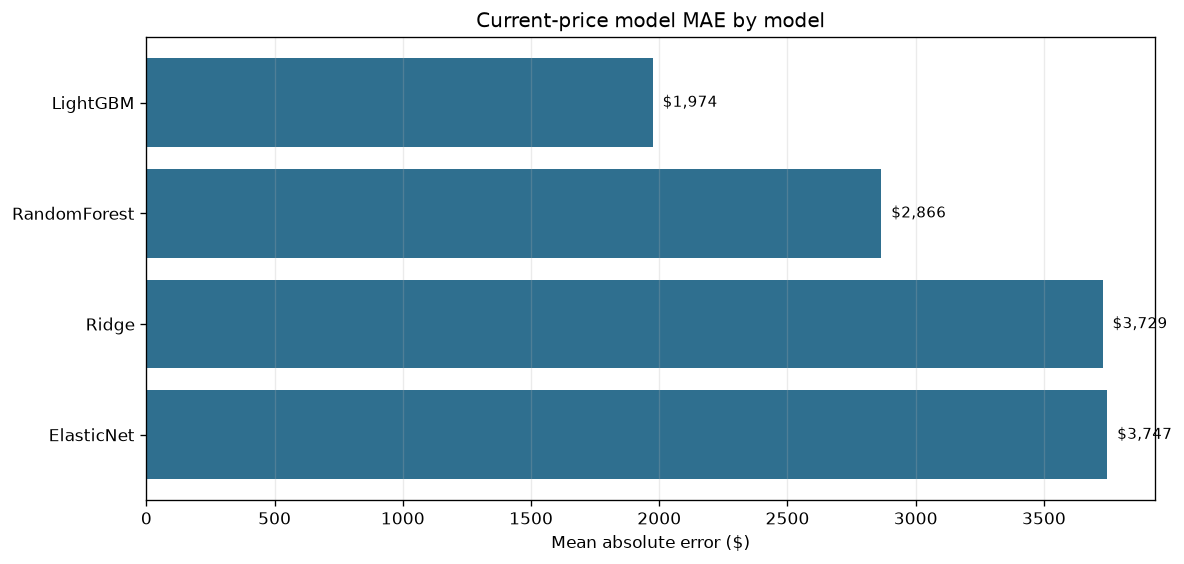

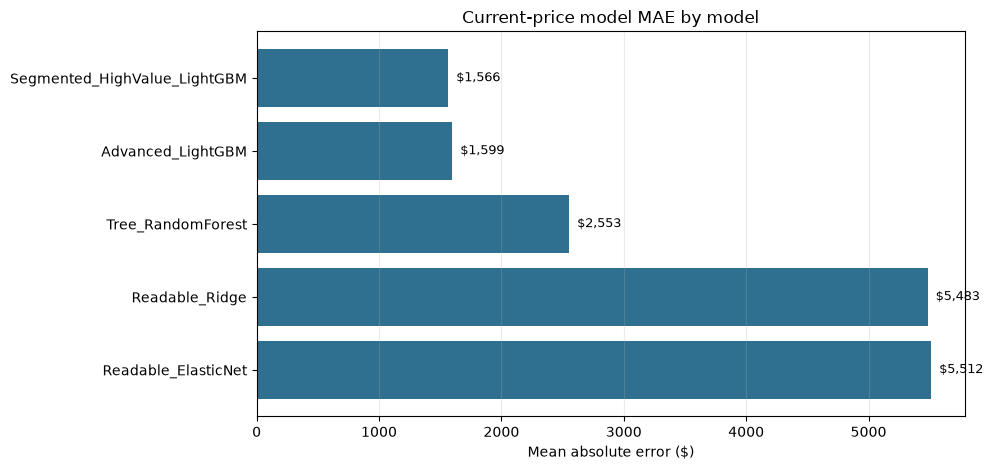

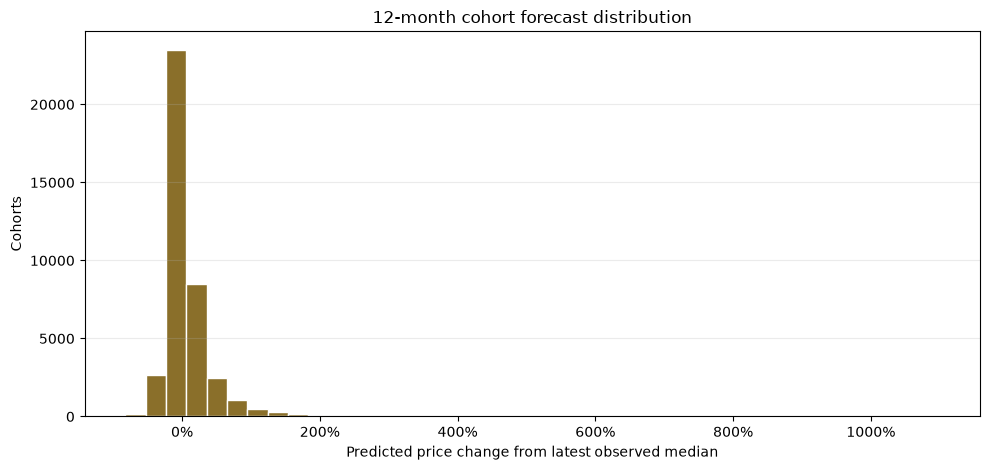

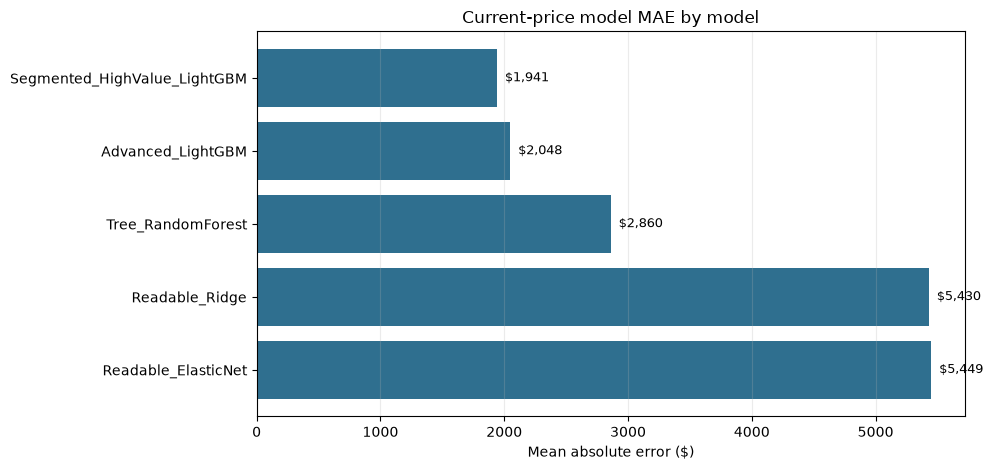

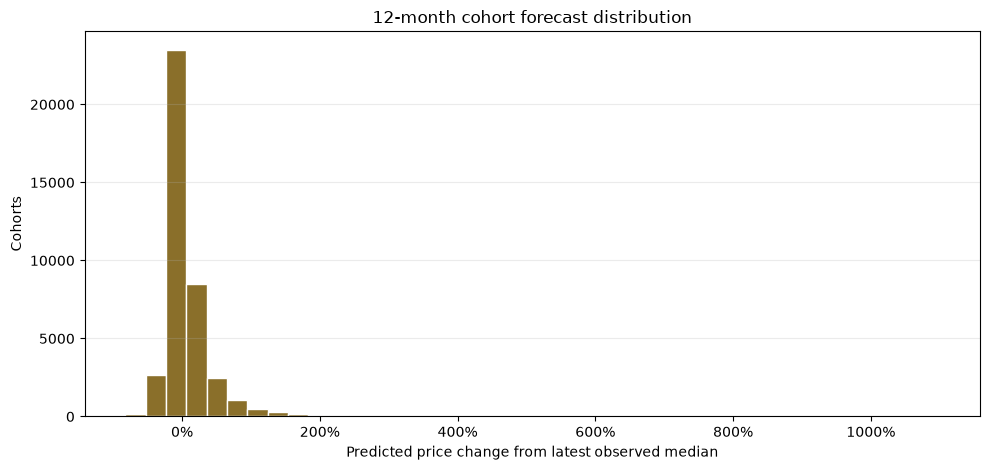

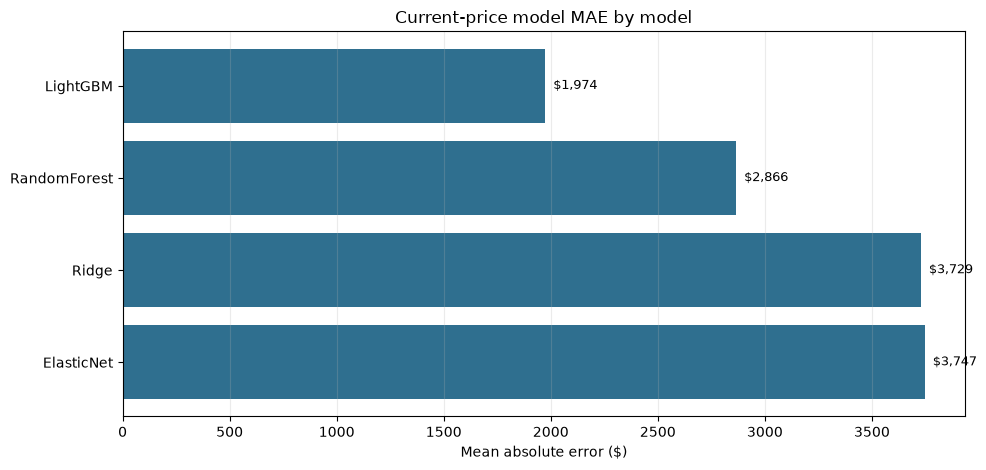

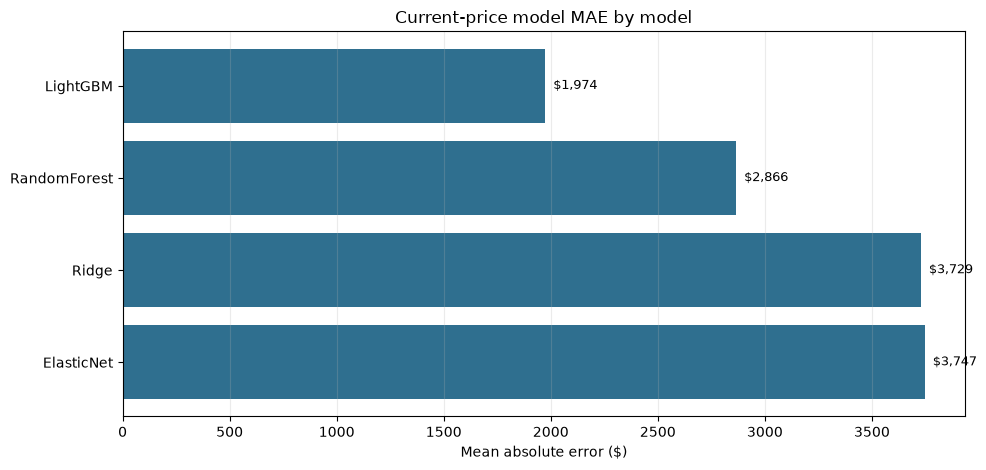

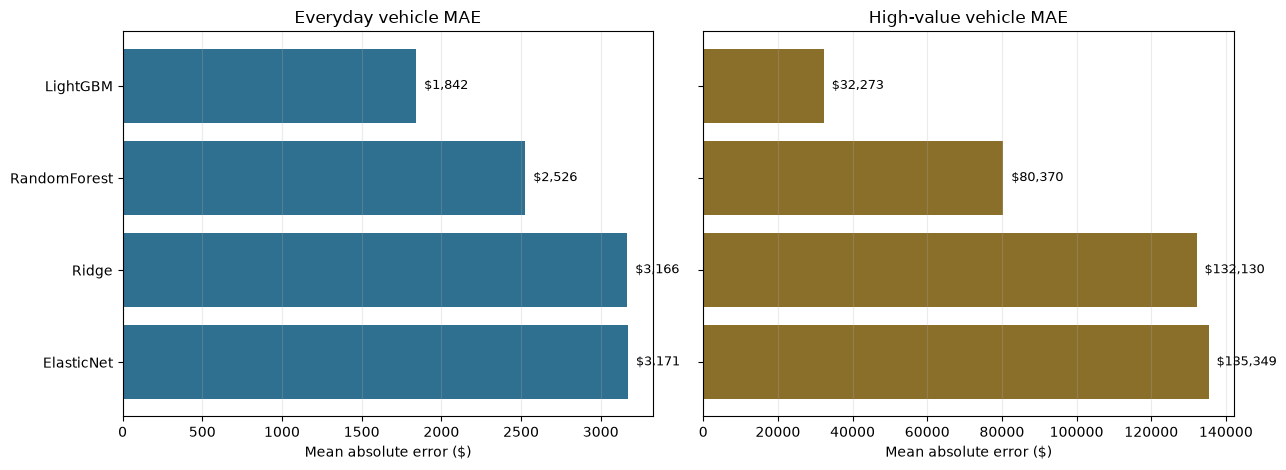

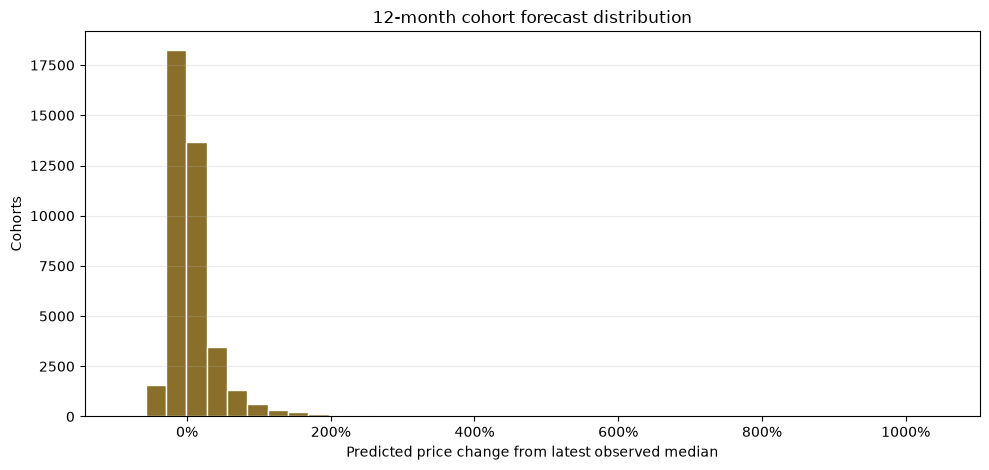

In [45]:
fig, ax = plt.subplots(figsize=(10, 4.8))
plot_df = current_model_kpis.sort_values("mae", ascending=True)
ax.barh(plot_df["model"], plot_df["mae"], color="#2f6f8f")
ax.set_title("Current-price model MAE by model")
ax.set_xlabel("Mean absolute error ($)")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.25)
for idx, value in enumerate(plot_df["mae"]):
    ax.text(value, idx, f"  ${value:,.0f}", va="center", fontsize=9)
plt.tight_layout()
show_matplotlib(fig)


## Feature Weights And Fit Footprint

The simple-model rows expose signed coefficients after preprocessing and scaling. Tree-family rows expose model-native feature importance, which is useful for ranking variables but should not be read as a causal effect.

In [46]:
def extract_weights_from_artifact(model_name: str, top_n: int = TOP_MODEL_WEIGHT_ROWS) -> list[dict]:
    path = OUTPUT_DIR / f"{model_name}.joblib"
    if not path.exists():
        return []
    try:
        model = joblib.load(path)
    except Exception as exc:
        print(f"Skipping artifact fallback for {model_name}: {exc}")
        return []
    if "preprocessor" not in model.named_steps or "model" not in model.named_steps:
        return []
    estimator = getattr(model.named_steps["model"], "regressor_", model.named_steps["model"])
    weight_type = "feature_importance"
    if hasattr(estimator, "coef_"):
        weights = np.ravel(estimator.coef_).astype(float)
        weight_type = "coefficient"
    elif hasattr(estimator, "feature_importances_"):
        weights = np.ravel(estimator.feature_importances_).astype(float)
    elif hasattr(estimator, "global_regressor_") and hasattr(estimator.global_regressor_, "feature_importances_"):
        weights = np.ravel(estimator.global_regressor_.feature_importances_).astype(float)
        weight_type = "global_feature_importance"
    else:
        return []
    try:
        feature_names = list(model.named_steps["preprocessor"].get_feature_names_out())
    except Exception:
        feature_names = [f"feature_{idx}" for idx in range(len(weights))]
    if len(feature_names) != len(weights):
        feature_names = [f"feature_{idx}" for idx in range(len(weights))]
    rows = [
        {
            "model": model_name,
            "feature": feature,
            "weight": float(weight),
            "abs_weight": abs(float(weight)),
            "weight_type": weight_type,
        }
        for feature, weight in zip(feature_names, weights)
    ]
    return sorted(rows, key=lambda row: row["abs_weight"], reverse=True)[:top_n]

def normalize_weight_row(row: dict, model_name: str) -> dict:
    weight = row.get("weight", row.get("importance", np.nan))
    abs_weight = row.get("abs_weight", abs(weight) if pd.notna(weight) else np.nan)
    return {
        "model": row.get("model", model_name),
        "feature": row.get("feature", ""),
        "weight": weight,
        "abs_weight": abs_weight,
        "weight_type": row.get("weight_type", "saved_report_weight"),
    }

feature_profile = current_report.get("feature_space_profile", {})
if feature_profile:
    display(
        pd.DataFrame(
            [
                {"metric": "raw pandas training frame", "value": f"{feature_profile.get('raw_pandas_training_frame_mb', np.nan):,.0f} MB"},
                {"metric": "profiled transformed shape", "value": str(tuple(feature_profile.get("transformed_shape_on_profile", [])))},
                {"metric": "transformed dtype", "value": feature_profile.get("transformed_dtype")},
                {"metric": "projected full transformed matrix", "value": f"{feature_profile.get('projected_full_training_matrix_memory_mb', np.nan) / 1024:,.2f} GB"},
            ]
        )
    )

weight_rows = []
saved_weights = current_report.get("model_feature_weights", {})
models_to_report = list(dict.fromkeys(["Ridge", "ElasticNet", best_model]))
for model_name in models_to_report:
    rows = saved_weights.get(model_name) or extract_weights_from_artifact(model_name)
    for rank, raw_row in enumerate(rows[:TOP_MODEL_WEIGHT_ROWS], start=1):
        row = normalize_weight_row(dict(raw_row), model_name)
        row["rank"] = rank
        weight_rows.append(row)

current_feature_weights = pd.DataFrame(weight_rows)
if current_feature_weights.empty:
    display(Markdown("No saved feature weights were found. Rerun `ML/Price_ML_Models.py` after the latest script update."))
else:
    display(Markdown(f"Showing the top {TOP_MODEL_WEIGHT_ROWS} weights/importances for Ridge, ElasticNet, and the selected best model."))
    display(
        current_feature_weights[["model", "rank", "feature", "weight", "abs_weight", "weight_type"]]
        .sort_values(["model", "rank"])
        .style.format({"weight": "{:.4g}", "abs_weight": "{:.4g}"})
    )

,metric,value
0,raw pandas training frame,"12,631 MB"
1,profiled transformed shape,"(200000, 335)"
2,transformed dtype,float32
3,projected full transformed matrix,3.34 GB


Showing the top 30 weights/importances for Ridge, ElasticNet, and the selected best model.

,model,rank,feature,weight,abs_weight,weight_type
30,ElasticNet,1,mileage_age_interaction,-0.3523,0.3523,global_coefficient
31,ElasticNet,2,vehicle_age_squared,0.09928,0.09928,global_coefficient
32,ElasticNet,3,target_encoded__title_normalized,0.09019,0.09019,global_coefficient
33,ElasticNet,4,nhtsa_DisplacementL,0.0854,0.0854,global_coefficient
34,ElasticNet,5,target_encoded__nhtsa_Model,0.08258,0.08258,global_coefficient
35,ElasticNet,6,mileage_bucket_150k_plus,-0.05927,0.05927,global_coefficient
36,ElasticNet,7,nhtsa_EngineCylinders,0.05146,0.05146,global_coefficient
37,ElasticNet,8,target_encoded__nhtsa_EngineManufacturer,-0.04559,0.04559,global_coefficient
38,ElasticNet,9,mileage,-0.04191,0.04191,global_coefficient
39,ElasticNet,10,mileage_bucket_100k_150k,-0.04131,0.04131,global_coefficient


## Segment Checks

The all-model split below separates everyday vehicles from the high-value tail saved by `ML/Price_ML_Models.py`. Use these rows alongside the global leaderboard because a small number of high-value vehicles can dominate RMSE and R2 for readable linear models even when everyday-vehicle MAE is much closer.

### Everyday vs High-Value Performance By Model

,model,mae,rmse,r2,everyday_rows,everyday_mae,high_value_rows,high_value_mae,high_value_mae_lift
1,LightGBM,"$1,974","$6,265",0.938,"666,748","$1,842","2,920","$32,273",17.5x
2,RandomForest,"$2,866","$11,060",0.807,"666,748","$2,526","2,920","$80,370",31.8x
3,Ridge,"$3,729","$42,871",-1.900,"666,748","$3,166","2,920","$132,130",41.7x
0,ElasticNet,"$3,747","$44,531",-2.129,"666,748","$3,171","2,920","$135,349",42.7x


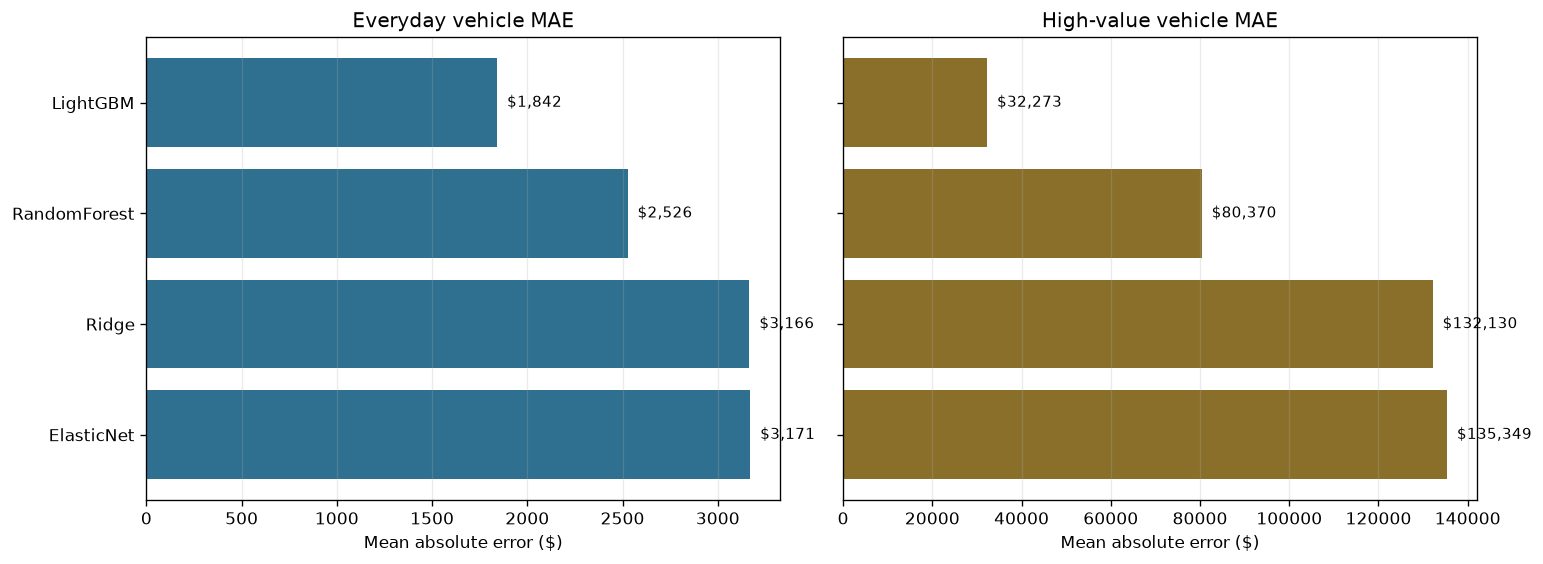

### `LightGBM` Price Band MAE

,segment,rows,mae
0,150k_plus,"2,918","$32,285"
1,100k_150k,"3,288","$18,688"
2,50k_100k,"57,115","$4,080"
3,25k_50k,"289,993","$1,725"
4,under_25k,"316,354","$1,369"


### `LightGBM` Highest-MAE Makes With At Least 100 Test Rows

,segment,rows,mae
0,FERRARI,630,"$44,787"
1,LAMBORGHINI,547,"$37,424"
2,MCLAREN,216,"$31,160"
3,PORSCHE,"8,616","$9,049"
4,MASERATI,965,"$4,532"
5,JAGUAR,"1,346","$3,287"
6,CADILLAC,"10,111","$2,853"
7,BMW,"26,884","$2,805"
8,DODGE,"15,345","$2,486"
9,FORD,"62,551","$2,425"


In [47]:
value_segment_kpis = current_value_segment_table(current_report)
if value_segment_kpis.empty:
    display(Markdown("No everyday/high-value segment metrics were found. Rerun `ML/Price_ML_Models.py` with the latest segment metric output."))
else:
    value_segment_kpis = (
        value_segment_kpis
        .merge(current_model_kpis[["model", "mae", "rmse", "r2"]], on="model", how="left")
        .sort_values("everyday_mae")
    )
    display(Markdown("### Everyday vs High-Value Performance By Model"))
    display(
        value_segment_kpis[
            [
                "model",
                "mae",
                "rmse",
                "r2",
                "everyday_rows",
                "everyday_mae",
                "high_value_rows",
                "high_value_mae",
                "high_value_mae_lift",
            ]
        ].style.format(
            {
                "mae": "${:,.0f}",
                "rmse": "${:,.0f}",
                "r2": "{:.3f}",
                "everyday_rows": "{:,.0f}",
                "everyday_mae": "${:,.0f}",
                "high_value_rows": "{:,.0f}",
                "high_value_mae": "${:,.0f}",
                "high_value_mae_lift": "{:.1f}x",
            },
            na_rep="",
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
    plot_segments = value_segment_kpis.sort_values("everyday_mae")
    axes[0].barh(plot_segments["model"], plot_segments["everyday_mae"], color="#2f6f8f")
    axes[0].set_title("Everyday vehicle MAE")
    axes[0].set_xlabel("Mean absolute error ($)")
    axes[0].invert_yaxis()
    axes[0].grid(axis="x", alpha=0.25)
    for idx, value in enumerate(plot_segments["everyday_mae"]):
        axes[0].text(value, idx, f"  ${value:,.0f}", va="center", fontsize=9)

    axes[1].barh(plot_segments["model"], plot_segments["high_value_mae"], color="#8a6f2a")
    axes[1].set_title("High-value vehicle MAE")
    axes[1].set_xlabel("Mean absolute error ($)")
    axes[1].grid(axis="x", alpha=0.25)
    for idx, value in enumerate(plot_segments["high_value_mae"]):
        axes[1].text(value, idx, f"  ${value:,.0f}", va="center", fontsize=9)
    plt.tight_layout()
    show_matplotlib(fig)

best_segment_metrics = current_report["models"][best_model].get("segment_metrics", {})

def segment_table(segment_name: str, min_rows: int = 1) -> pd.DataFrame:
    rows = []
    for segment_value, stats in best_segment_metrics.get(segment_name, {}).items():
        rows.append(
            {
                "segment": segment_value,
                "rows": stats.get("rows", 0),
                "mae": stats.get("mae", np.nan),
            }
        )
    if not rows:
        return pd.DataFrame(columns=["segment", "rows", "mae"])
    return (
        pd.DataFrame(rows)
        .query("rows >= @min_rows")
        .sort_values("mae", ascending=False)
        .reset_index(drop=True)
    )

price_band_check = segment_table("price_band")
make_check = segment_table("nhtsa_Make", min_rows=100).head(12)

display(Markdown(f"### `{best_model}` Price Band MAE"))
display(price_band_check.style.format({"rows": "{:,.0f}", "mae": "${:,.0f}"}))
display(Markdown(f"### `{best_model}` Highest-MAE Makes With At Least 100 Test Rows"))
display(make_check.style.format({"rows": "{:,.0f}", "mae": "${:,.0f}"}))

## Cohort Forecast Model Results

The time-series script trains cohort-level depreciation forecasts by make, model, model year, and trim proxy. The benchmark can include the global supervised ML model, SARIMAX, Prophet, and TimesFM. Each validated model family is compared against a no-change baseline with future-price MAE, WAPE, depreciation error, and skill-vs-naive KPIs. Optional dependencies or insufficient cohort history are recorded as skip reasons instead of failing the report.

In [48]:
cohort_rows = []
for model_key, model in cohort_report.get("models", {}).items():
    metrics = model.get("metrics", {})
    target_name = model.get("target") or model_key
    cohort_rows.append(
        {
            "model_key": model_key,
            "target": target_name,
            "model_family": model.get("model_family", "global_ml"),
            "forecast_method": model.get("forecast_method"),
            "horizon_months": horizon_months_from_target(target_name),
            "status": "skipped" if model.get("skipped") else ("validated" if metrics else "trained_no_validation"),
            "complete_rows": model.get("complete_rows"),
            "train_rows": model.get("train_rows"),
            "test_rows": model.get("test_rows"),
            "backtest_rows": metrics.get("backtest_rows", model.get("test_rows")),
            "backtest_cohorts": metrics.get("backtest_cohorts", model.get("test_cohorts")),
            "future_price_mae": metrics.get("future_price_mae"),
            "future_price_wape": metrics.get("future_price_wape"),
            "naive_mae": metrics.get("naive_no_change_future_price_mae"),
            "skill_vs_naive": metrics.get("future_price_mae_skill_vs_naive"),
            "beats_naive": metrics.get("future_price_mae_skill_vs_naive", np.nan) > 0,
            "depreciation_mae_pct_points": metrics.get("depreciation_mae_pct_points"),
            "bias_dollars": metrics.get("future_price_bias"),
            "depreciation_r2": metrics.get("depreciation_r2"),
            "skip_reason": model.get("skipped") or model.get("validation_warning"),
        }
    )

cohort_kpis = pd.DataFrame(cohort_rows).sort_values(["status", "horizon_months", "model_family"])
validated = cohort_kpis.dropna(subset=["skill_vs_naive"]).copy()
if not validated.empty:
    best = validated.sort_values(["skill_vs_naive", "future_price_wape"], ascending=[False, True]).iloc[0]
    display(Markdown(f"**Best validated time-series model:** `{best['model_family']}` on `{best['target']}`, skill {pct(best['skill_vs_naive'])}, WAPE {pct(best['future_price_wape'])}, MAE {money(best['future_price_mae'])}."))
cohort_kpis.style.format(
    {
        "future_price_mae": "${:,.0f}",
        "future_price_wape": "{:.1%}",
        "naive_mae": "${:,.0f}",
        "skill_vs_naive": "{:.1%}",
        "depreciation_mae_pct_points": "{:.2f}",
        "bias_dollars": "${:,.0f}",
        "depreciation_r2": "{:.3f}",
    },
    na_rep="",
)

**Best validated time-series horizon by skill vs naive:** `target_depreciation_pct_1m` (1 month), skill -14.0%, WAPE 5.4%, MAE $2,290.

,target,horizon_months,status,complete_rows,train_rows,test_rows,future_price_mae,future_price_wape,naive_mae,skill_vs_naive,beats_naive,depreciation_mae_pct_points,bias_dollars,depreciation_r2,skip_reason
0,target_depreciation_pct_1m,1,trained,50887,40939,7824,"$2,290",5.4%,"$2,010",-14.0%,False,6.64,$-429,0.164,


## Time-Series Feature Importance

Feature importance is available for the global ML cohort model artifacts. SARIMAX, Prophet, and TimesFM are reported through their forecast and backtesting KPIs rather than model-native feature weights.

In [49]:
def cohort_feature_importance_for_target(model_key: str, top_n: int = TOP_MODEL_WEIGHT_ROWS) -> pd.DataFrame:
    model_report = cohort_report.get("models", {}).get(model_key, {})
    rows = model_report.get("feature_importance") or []
    if not rows and model_report.get("artifact"):
        path = OUTPUT_DIR / model_report["artifact"]
        if path.exists():
            try:
                model = joblib.load(path)
            except Exception as exc:
                print(f"Skipping cohort artifact fallback for {model_key}: {exc}")
                model = None
            if model is not None:
                estimator = model.named_steps.get("model")
                if hasattr(estimator, "feature_importances_"):
                    weights = np.ravel(estimator.feature_importances_).astype(float)
                    try:
                        feature_names = list(model.named_steps["preprocessor"].get_feature_names_out())
                    except Exception:
                        feature_names = [f"feature_{idx}" for idx in range(len(weights))]
                    if len(feature_names) != len(weights):
                        feature_names = [f"feature_{idx}" for idx in range(len(weights))]
                    rows = [
                        {"feature": feature, "importance": float(weight), "abs_weight": abs(float(weight)), "weight_type": "feature_importance"}
                        for feature, weight in zip(feature_names, weights)
                    ]
    if not rows:
        return pd.DataFrame()
    out = pd.DataFrame(rows).sort_values("abs_weight", ascending=False).head(top_n).reset_index(drop=True)
    out.insert(0, "rank", np.arange(1, len(out) + 1))
    return out

global_candidates = [
    row for _, row in cohort_summary.iterrows()
    if row.get("model_family") == "global_ml" and pd.notna(row.get("skill_vs_naive"))
] if not cohort_summary.empty else []
if not global_candidates:
    display(Markdown("No validated global ML cohort model metrics were found."))
else:
    best_global = pd.DataFrame(global_candidates).sort_values(["skill_vs_naive", "future_price_wape"], ascending=[False, True]).iloc[0]
    cohort_feature_importance = cohort_feature_importance_for_target(best_global["model_key"])
    if cohort_feature_importance.empty:
        display(Markdown("No feature importance was found for the best global cohort model. Rerun `ML/Time_Series_Price.py` after the latest script update."))
    else:
        display(Markdown(f"### Top {TOP_MODEL_WEIGHT_ROWS} drivers for `{best_global['model_key']}`"))
        display(cohort_feature_importance[["rank", "feature", "importance", "abs_weight", "weight_type"]].style.format({"importance": "{:,.0f}", "abs_weight": "{:,.0f}"}))

### Top 30 drivers for `target_depreciation_pct_1m`

,rank,feature,importance,abs_weight,weight_type
0,1,price_index_vs_cohort_first,"3,445","3,445",feature_importance
1,2,lag_price_index_1,"3,366","3,366",feature_importance
2,3,rolling_depreciation_pct_3m,"2,716","2,716",feature_importance
3,4,median_price,"2,193","2,193",feature_importance
4,5,avg_vehicle_age_months,"2,008","2,008",feature_importance
5,6,rolling_avg_mileage_3m,"1,869","1,869",feature_importance
6,7,avg_miles_per_year,"1,804","1,804",feature_importance
7,8,cohort_age_months,"1,732","1,732",feature_importance
8,9,market_monthly_volume,"1,710","1,710",feature_importance
9,10,lag_median_price_2,"1,645","1,645",feature_importance


In [50]:
if forecast_df.empty:
    display(Markdown("No forecast CSV was found. Run `ML/Time_Series_Price.py` to generate `cohort_future_forecasts.csv`."))
else:
    observed_col = "observed_month_start" if "observed_month_start" in forecast_df.columns else "observed_week_start"
    horizon_col = "forecast_month" if "forecast_month" in forecast_df.columns else "forecast_horizon_days"
    horizon_label = "max forecast month" if horizon_col == "forecast_month" else "max horizon days"
    model_col = "model_family" if "model_family" in forecast_df.columns else "forecast_method"
    coverage = pd.DataFrame(
        [
            {"metric": "forecast rows", "value": f"{len(forecast_df):,}"},
            {"metric": "model families", "value": f"{forecast_df[model_col].nunique():,}"},
            {"metric": "cohorts", "value": f"{forecast_df[['make', 'model', 'model_year', 'trim_proxy']].drop_duplicates().shape[0]:,}"},
            {"metric": "last observed period", "value": str(forecast_df[observed_col].max().date())},
            {"metric": "max forecast date", "value": str(forecast_df["forecast_date"].max().date())},
            {"metric": horizon_label, "value": f"{forecast_df[horizon_col].max():,.0f}"},
        ]
    )
    display(coverage)
    display(
        forecast_df.groupby([model_col, "forecast_method", horizon_col], as_index=False)
        .size()
        .rename(columns={"size": "rows"})
        .sort_values([horizon_col, model_col, "forecast_method"])
        .tail(30)
    )

if backtest_kpis_df.empty:
    display(Markdown("No backtesting KPI CSV was found. Run `ML/Time_Series_Price.py` to generate `cohort_backtesting_kpis.csv`."))
else:
    model_horizon_kpis = backtest_kpis_df[backtest_kpis_df["kpi_scope"].eq("model_horizon")].copy()
    display(Markdown("### Backtesting KPI table"))
    display(
        model_horizon_kpis.sort_values(["forecast_month", "future_price_mae"])
        .style.format(
            {
                "future_price_mae": "${:,.0f}",
                "future_price_wape": "{:.1%}",
                "future_price_mae_skill_vs_naive": "{:.1%}",
                "future_price_bias": "${:,.0f}",
                "depreciation_mae_pct_points": "{:.2f}",
            },
            na_rep="",
        )
    )

,metric,value
0,forecast rows,"2,399,880"
1,cohorts,"39,998"
2,last observed period,2026-07-01
3,max forecast date,2031-07-01
4,max forecast month,60


,forecast_method,forecast_month,rows
40,recursive_1m_model,41,39998
41,recursive_1m_model,42,39998
42,recursive_1m_model,43,39998
43,recursive_1m_model,44,39998
44,recursive_1m_model,45,39998
45,recursive_1m_model,46,39998
46,recursive_1m_model,47,39998
47,recursive_1m_model,48,39998
48,recursive_1m_model,49,39998
49,recursive_1m_model,50,39998


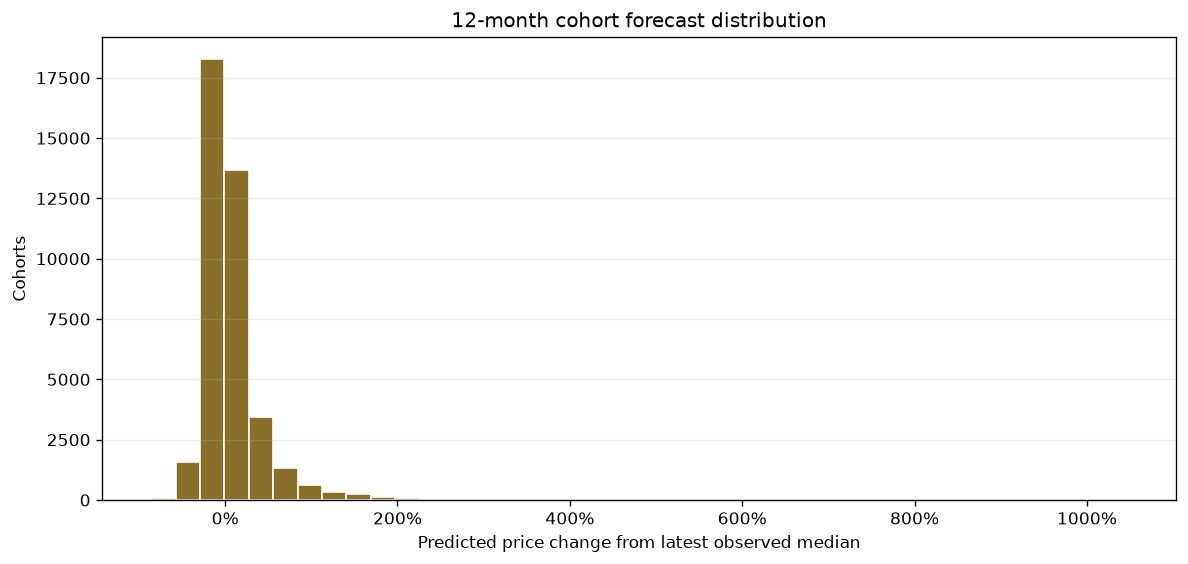

,predicted_depreciation_pct
count,3999800.0%
mean,8.6%
std,41.0%
min,-85.9%
10%,-19.6%
25%,-9.6%
50%,-0.9%
75%,14.5%
90%,43.7%
max,1046.8%


In [51]:
if not forecast_df.empty:
    horizon_col = "forecast_month" if "forecast_month" in forecast_df.columns else "forecast_horizon_days"
    target_horizon = 12 if horizon_col == "forecast_month" and forecast_df[horizon_col].max() >= 12 else forecast_df[horizon_col].max()
    if pd.notna(target_horizon):
        horizon_frame = forecast_df[forecast_df[horizon_col].eq(target_horizon)].copy()
        horizon_frame["predicted_depreciation_pct"] = pd.to_numeric(horizon_frame["predicted_depreciation_pct"], errors="coerce")
        model_col = "model_family" if "model_family" in horizon_frame.columns else "forecast_method"
        horizon_label = f"{int(target_horizon)}-month" if horizon_col == "forecast_month" else f"{int(target_horizon)}-day"
        fig, ax = plt.subplots(figsize=(10, 4.8))
        for model_family, family_df in horizon_frame.groupby(model_col):
            ax.hist(
                family_df["predicted_depreciation_pct"].dropna(),
                bins=35,
                alpha=0.45,
                label=str(model_family),
                edgecolor="white",
            )
        ax.set_title(f"{horizon_label.capitalize()} cohort forecast distribution by model family")
        ax.set_xlabel("Predicted price change from latest observed median")
        ax.set_ylabel("Cohort forecast rows")
        ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
        ax.grid(axis="y", alpha=0.25)
        ax.legend()
        plt.tight_layout()
        show_matplotlib(fig)

        horizon_summary = horizon_frame.groupby(model_col)["predicted_depreciation_pct"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
        display(horizon_summary.style.format("{:.1%}"))

if not backtest_results_df.empty:
    display(Markdown("### Cohort-level backtest sample"))
    sample_cols = [
        "model_family",
        "forecast_method",
        "make",
        "model",
        "model_year",
        "trim_proxy",
        "forecast_month",
        "observed_median_price",
        "actual_median_price",
        "predicted_median_price",
        "absolute_error",
        "naive_absolute_error",
    ]
    display(
        backtest_results_df[[col for col in sample_cols if col in backtest_results_df.columns]]
        .sort_values(["forecast_month", "absolute_error"])
        .head(50)
        .style.format(
            {
                "observed_median_price": "${:,.0f}",
                "actual_median_price": "${:,.0f}",
                "predicted_median_price": "${:,.0f}",
                "absolute_error": "${:,.0f}",
                "naive_absolute_error": "${:,.0f}",
            },
            na_rep="",
        )
    )

## Takeaways

- The current-price model should be monitored with the global KPI table and the everyday/high-value split. The split is especially important for Ridge and ElasticNet because a small high-value tail can inflate RMSE and push R2 negative while everyday-vehicle MAE remains far lower than the headline error suggests.
- In the latest saved report, every current-price candidate uses the same high-value router design from `ML/Price_ML_Models.py`; compare everyday MAE, high-value MAE, and the high-value MAE lift before deciding whether readable baselines are acceptable for regular vehicles.
- Ridge and ElasticNet now expose saved signed coefficients directly from `model_report.json`; the notebook no longer depends on older `Readable_*` artifact names to show readable-model weights.
- The cohort forecast model reports baseline skill, WAPE, and bias in addition to depreciation error. If the best validated horizon has negative skill versus the no-change baseline, treat recursive forecasts as directional scenarios rather than a proven improvement.
- The cohort forecast output is monthly and currently extends to the report's `max_forecast_date`. Use the forecast coverage table to confirm row counts, cohort counts, and forecast-month span after each model run.

## Sources

- scikit-learn, [Metrics and scoring: quantifying the quality of predictions](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics)
- Hyndman and Athanasopoulos, [Forecasting: Principles and Practice, Evaluating point forecast accuracy](https://otexts.com/fpp3/accuracy.html)
- Hyndman and Koehler, [Another look at measures of forecast accuracy](https://robjhyndman.com/publications/another-look-at-measures-of-forecast-accuracy/)
- Pal et al., [How much is my car worth? A methodology for predicting used cars prices using Random Forest](https://arxiv.org/abs/1711.06970)
- Madhusudhanan et al., [ProbSAINT: Probabilistic Tabular Regression for Used Car Pricing](https://arxiv.org/abs/2403.03812)
- Montero-Manso and Hyndman, [Principles and Algorithms for Forecasting Groups of Time Series: Locality and Globality](https://arxiv.org/abs/2008.00444)
- Hewamalage, Bergmeir, and Bandara, [Global Models for Time Series Forecasting: A Simulation Study](https://arxiv.org/abs/2012.12485)
- Manheim, [Used Vehicle Value Index Summary Methodology](https://site.manheim.com/wp-content/uploads/sites/2/2024/02/Used-Vehicle-Summary-Methodology.pdf)
